Generando programa base de OMIE...
Simulando proceso estocástico para la señal AGC...
Generando renderizado de la co-optimización...


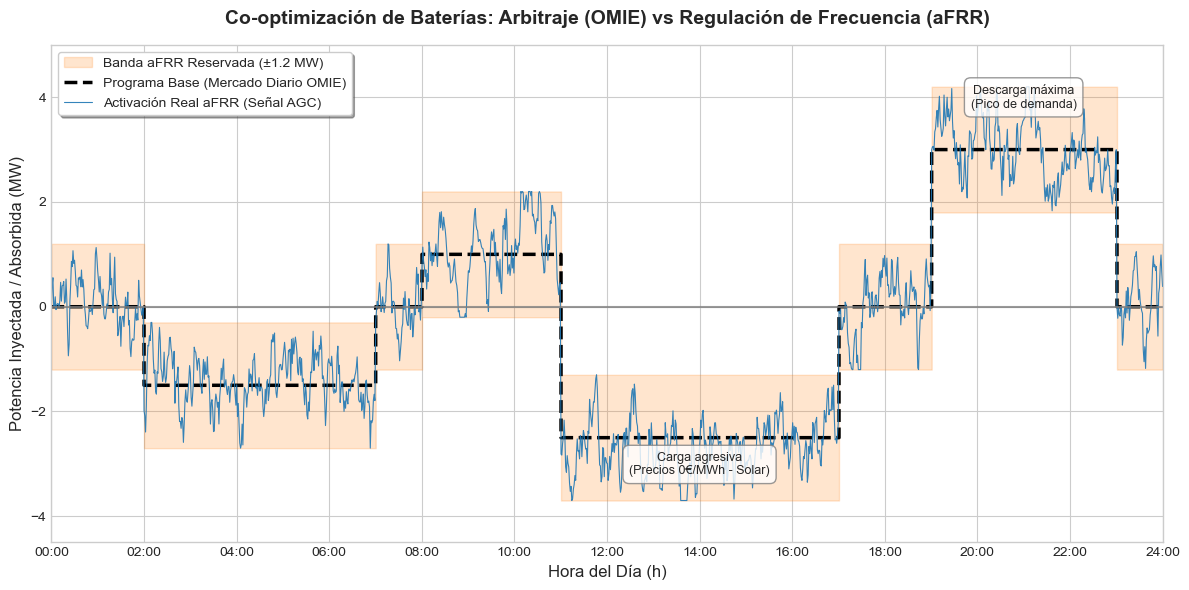

In [1]:
"""
Análisis Tecno-Económico del Agregador en España
Co-optimización de Baterías: Mercado Diario (OMIE) vs Regulación Secundaria (aFRR)

Este script simula el perfil operativo de un Sistema de Almacenamiento (BESS) 
participando simultáneamente en dos mercados. Se genera un programa base de 
arbitraje en OMIE y se superpone una simulación estocástica de la señal AGC 
(Control Automático de Generación) para el mercado de banda de regulación aFRR, 
modelada mediante un proceso de reversión a la media.

Autor: Alberto Zafra Muñoz
"""

import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple

# ==========================================
# 1. MODELADO DEL MERCADO Y CONTROL
# ==========================================
def generar_programa_omie(horas: np.ndarray) -> np.ndarray:
    """
    Genera el programa base de carga/descarga casado en el Mercado Diario (OMIE).
    Basado en la curva de precios española (Curva del Pato / Vertido Solar).
    
    Parámetros:
        horas (np.ndarray): Vector temporal continuo.
        
    Retorna:
        np.ndarray: Vector de potencia programada en MW (Positivo = Inyección).
    """
    programa = np.zeros_like(horas)
    for i, h in enumerate(horas):
        if 2 <= h < 7:
            programa[i] = -1.5  # Carga en valle nocturno
        elif 8 <= h < 11:
            programa[i] = 1.0   # Descarga en pico de la mañana
        elif 11 <= h < 17:
            programa[i] = -2.5  # Carga intensiva (Máxima generación solar)
        elif 19 <= h < 23:
            programa[i] = 3.0   # Descarga intensiva (Pico de demanda vespertino)
        else:
            programa[i] = 0.0   # Periodo inactivo
            
    return programa

def simular_senal_agc(
    longitud: int, 
    banda_mw: float, 
    theta: float = 0.85, 
    volatilidad: float = 0.3, 
    semilla: int = 10
) -> np.ndarray:
    """
    Simula la señal de consigna del operador del sistema (AGC) mediante un 
    proceso estocástico autoregresivo con reversión a la media.
    
    Parámetros:
        longitud (int): Número de instantes de tiempo a simular.
        banda_mw (float): Capacidad máxima reservada (MW) para regulación.
        theta (float): Parámetro de inercia/reversión a la media (0 a 1).
        volatilidad (float): Desviación típica del ruido gaussiano inyectado.
        semilla (int): Semilla para la reproducibilidad del proceso estocástico.
        
    Retorna:
        np.ndarray: Serie temporal de la activación de energía de regulación.
    """
    np.random.seed(semilla)
    ruido_agc = np.zeros(longitud)
    
    for t in range(1, longitud):
        # Ecuación diferencial estocástica discretizada (reversión a media 0)
        ruido_agc[t] = theta * ruido_agc[t-1] + np.random.normal(0, volatilidad)
        
    # Saturación física: el operador no puede pedir más potencia que la banda reservada
    ruido_agc = np.clip(ruido_agc, -banda_mw, banda_mw)
    
    return ruido_agc

# ==========================================
# 2. REPRESENTACIÓN GRÁFICA ACADÉMICA
# ==========================================
def visualizar_cooptimizacion(
    horas: np.ndarray, 
    prog_omie: np.ndarray, 
    banda: float, 
    potencia_final: np.ndarray
):
    """
    Genera el gráfico superponiendo el arbitraje base y la activación secundaria.
    """
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 6))

    # 1. Trazado de la banda de capacidad aFRR (Sombreado)
    ax.fill_between(
        horas, prog_omie - banda, prog_omie + banda,
        step='post', color='#ff7f0e', alpha=0.2,
        label=f'Banda aFRR Reservada (±{banda} MW)'
    )

    # 2. Trazado del programa base del Mercado Diario
    ax.step(
        horas, prog_omie, where='post', 
        label='Programa Base (Mercado Diario OMIE)',
        color='black', linewidth=2.5, linestyle='--'
    )

    # 3. Trazado de la entrega real de energía (Base + Activación AGC)
    ax.plot(
        horas, potencia_final, color='#1f77b4', linewidth=0.8, alpha=0.9,
        label='Activación Real aFRR (Señal AGC)'
    )

    # 4. Formateo y Anotaciones
    ax.set_title('Co-optimización de Baterías: Arbitraje (OMIE) vs Regulación de Frecuencia (aFRR)',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Hora del Día (h)', fontsize=12)
    ax.set_ylabel('Potencia Inyectada / Absorbida (MW)', fontsize=12)
    ax.axhline(0, color='gray', linewidth=1.5, alpha=0.8)

    # Configuración del eje X (Formato horario)
    ax.set_xlim(0, 24)
    ax.set_xticks(np.arange(0, 25, 2))
    ax.set_xticklabels([f'{h:02d}:00' for h in np.arange(0, 25, 2)])
    ax.set_ylim(-4.5, 5)

    # Cuadros de texto explicativos para los picos de operación
    caja_estilo = dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.5')
    ax.text(14, -3.2, 'Carga agresiva\n(Precios 0€/MWh - Solar)', 
            ha='center', fontsize=9, bbox=caja_estilo)
    ax.text(21, 3.8, 'Descarga máxima\n(Pico de demanda)', 
            ha='center', fontsize=9, bbox=caja_estilo)

    ax.legend(loc='upper left', fontsize=10, frameon=True, shadow=True)

    plt.tight_layout()
    # Opcional: Descomentar la siguiente línea para guardar la imagen automáticamente
    # plt.savefig('Fig_2_7_Cooptimizacion.png', format='png', dpi=300)
    plt.show()

# ==========================================
# 3. BLOQUE PRINCIPAL DE EJECUCIÓN
# ==========================================
if __name__ == "__main__":
    # Definición del vector temporal (24h con resolución de 1 minuto)
    resolucion_minutos = 24 * 60
    vector_horas = np.linspace(0, 24, resolucion_minutos)
    
    # Parámetros del mercado de reserva
    BANDA_RESERVA_MW = 1.2
    
    print("Generando programa base de OMIE...")
    omie = generar_programa_omie(vector_horas)
    
    print("Simulando proceso estocástico para la señal AGC...")
    activacion_agc = simular_senal_agc(resolucion_minutos, BANDA_RESERVA_MW)
    
    # Ecuación de balance nodal: La potencia real es el programa base más el desvío pedido por el OS
    potencia_neta_bateria = omie + activacion_agc
    
    print("Generando renderizado de la co-optimización...")
    visualizar_cooptimizacion(vector_horas, omie, BANDA_RESERVA_MW, potencia_neta_bateria)